#  Pneumonia Detection System — Data Visualization
**ENSA Tanger — Practical Intelligence Systems 2025-2026**

Members: El Fajri Youssef · El Alami Hassoun Mohamed · El Amrani Alae · El Aouzi Walid

---
This notebook covers a complete **Exploratory Data Analysis (EDA)** of the Chest X-Ray dataset:
1. Dataset structure & class distribution
2. Sample image visualization
3. Image dimension analysis
4. Pixel intensity statistics
5. HOG feature visualization
6. Data augmentation preview
7. Class imbalance analysis

## 0. Imports & Configuration

In [14]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
from pathlib import Path
from skimage.feature import hog
from skimage import exposure
from tensorflow.keras.preprocessing.image import ImageDataGenerator

warnings.filterwarnings('ignore')
np.random.seed(42)
os.makedirs("Visualization", exist_ok=True)

# ─── Styling ───
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#e6edf3',
    'axes.titlecolor':  '#e6edf3',
    'text.color':       '#e6edf3',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

COLORS  = {'NORMAL': '#58a6ff', 'PNEUMONIA': '#f85149'}
PALETTE = ['#58a6ff', '#f85149']

# ─── Dataset path ───
DATA_DIR = Path('chest_xray')   # ← change if needed
CLASSES  = ['NORMAL', 'PNEUMONIA']
SPLITS   = ['train', 'val', 'test']

print('✅ Setup complete')
print(f'   Dataset path: {DATA_DIR.resolve()}')

✅ Setup complete
   Dataset path: C:\Users\elfaj\Documents\S4\PneumoniaDetectionSystem\chest_xray


---
## 1. Dataset Structure & Class Distribution

In [2]:
# ─── Count images per split / class ───
records = []
for split in SPLITS:
    for cls in CLASSES:
        folder = DATA_DIR / split / cls
        count  = len(list(folder.glob('*.jpeg'))) if folder.exists() else 0
        records.append({'Split': split, 'Class': cls, 'Count': count})

df_counts = pd.DataFrame(records)
pivot     = df_counts.pivot(index='Split', columns='Class', values='Count')
pivot['Total'] = pivot.sum(axis=1)
pivot['% PNEUMONIA'] = (pivot['PNEUMONIA'] / pivot['Total'] * 100).round(1)

print('=' * 52)
print('  DATASET SUMMARY')
print('=' * 52)
print(pivot.to_string())
print('=' * 52)

  DATASET SUMMARY
Class  NORMAL  PNEUMONIA  Total  % PNEUMONIA
Split                                       
test      234        390    624         62.5
train    1341       3875   5216         74.3
val         8          8     16         50.0


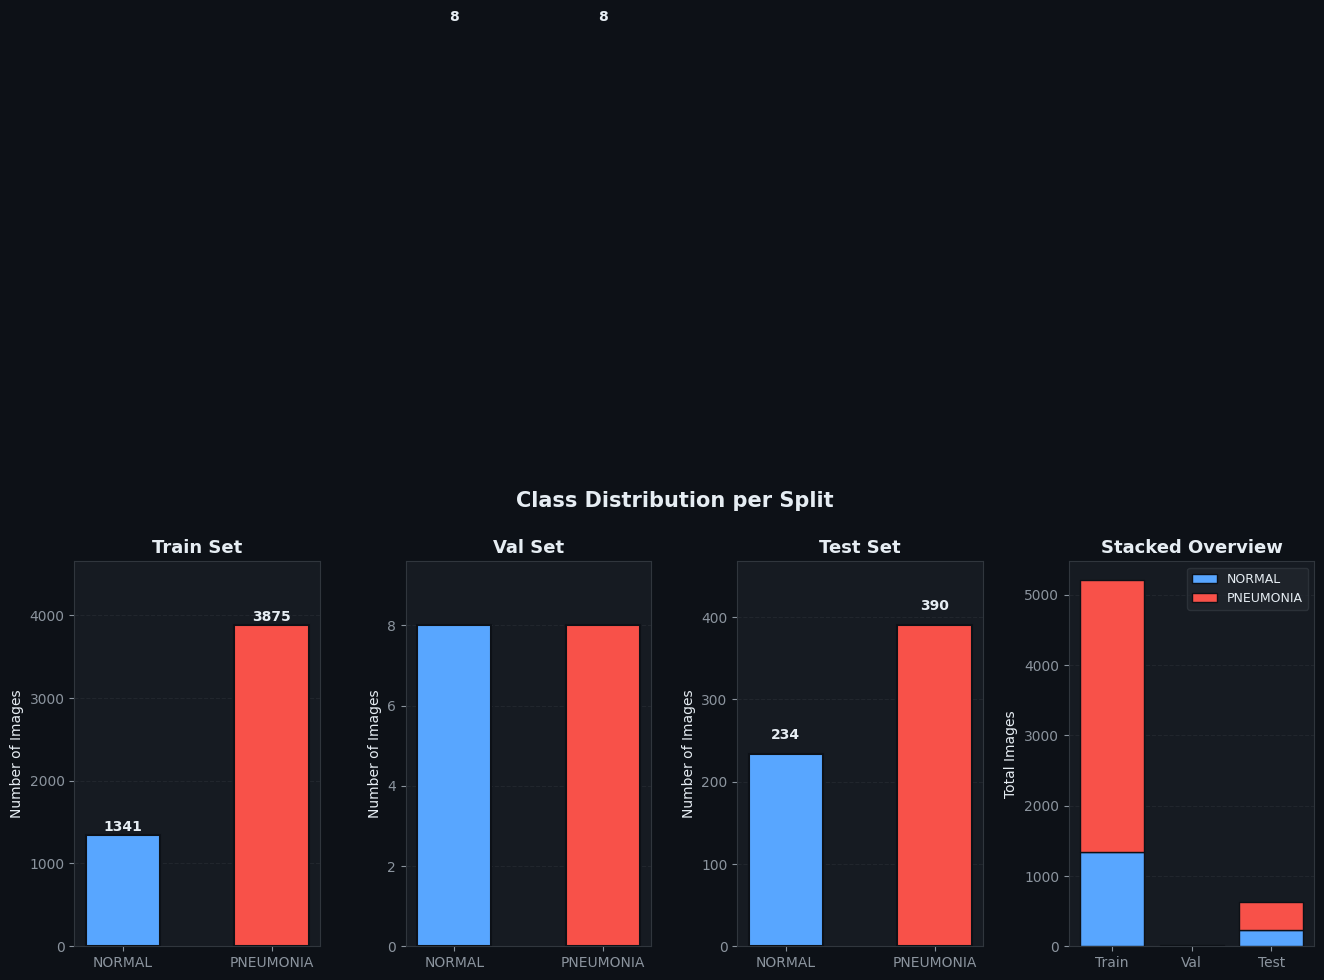

Saved: viz_01_class_distribution.png


In [15]:
fig = plt.figure(figsize=(16, 5), facecolor='#0d1117')
gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.35)

# ── Per-split bar charts ──
for i, split in enumerate(SPLITS):
    ax   = fig.add_subplot(gs[i])
    data = df_counts[df_counts['Split'] == split]
    bars = ax.bar(data['Class'], data['Count'],
                  color=PALETTE, edgecolor='#0d1117', linewidth=1.5,
                  width=0.5, zorder=3)
    for bar, val in zip(bars, data['Count']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                str(val), ha='center', va='bottom', fontsize=10,
                color='#e6edf3', fontweight='bold')
    ax.set_title(f'{split.capitalize()} Set')
    ax.set_ylabel('Number of Images')
    ax.set_ylim(0, data['Count'].max() * 1.2)
    ax.grid(axis='y', zorder=0)
    ax.set_facecolor('#161b22')

# ── Stacked bar (total overview) ──
ax4 = fig.add_subplot(gs[3])
x   = np.arange(len(SPLITS))
n_vals = [df_counts[(df_counts.Split==s) & (df_counts.Class=='NORMAL')]['Count'].values[0] for s in SPLITS]
p_vals = [df_counts[(df_counts.Split==s) & (df_counts.Class=='PNEUMONIA')]['Count'].values[0] for s in SPLITS]
ax4.bar(x, n_vals, color='#58a6ff', label='NORMAL',    edgecolor='#0d1117', zorder=3)
ax4.bar(x, p_vals, bottom=n_vals, color='#f85149', label='PNEUMONIA', edgecolor='#0d1117', zorder=3)
ax4.set_xticks(x)
ax4.set_xticklabels([s.capitalize() for s in SPLITS])
ax4.set_title('Stacked Overview')
ax4.set_ylabel('Total Images')
ax4.legend(fontsize=9, facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3')
ax4.grid(axis='y', zorder=0)
ax4.set_facecolor('#161b22')

fig.suptitle('Class Distribution per Split', fontsize=15, fontweight='bold',
             color='#e6edf3', y=1.02)
plt.savefig('Visualization/viz_01_class_distribution.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('Saved: viz_01_class_distribution.png')

---
## 2. Sample Image Visualization

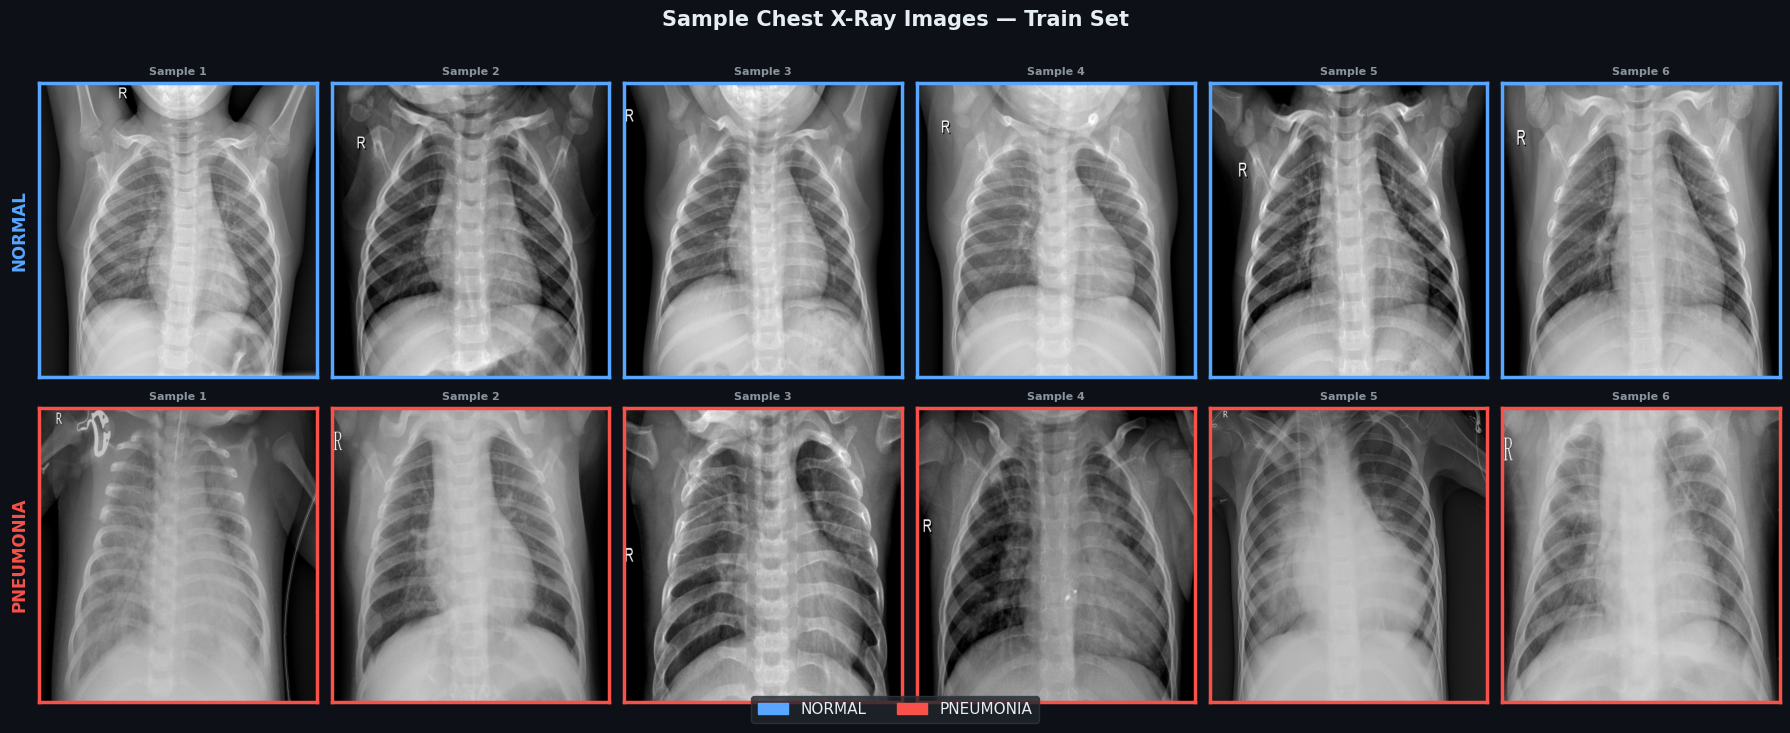

Saved: viz_02_sample_images.png


In [ ]:
def load_sample_images(split, cls, n=5):
    folder = DATA_DIR / split / cls
    paths  = sorted(folder.glob('*.jpeg'))[:n]
    imgs   = []
    for p in paths:
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            imgs.append(img)
    return imgs

fig, axes = plt.subplots(2, 6, figsize=(18, 7), facecolor='#0d1117')
fig.patch.set_facecolor('#0d1117')

for row, cls in enumerate(CLASSES):
    imgs = load_sample_images('train', cls, n=6)
    color = COLORS[cls]
    for col, img in enumerate(imgs):
        ax = axes[row, col]
        ax.imshow(img, cmap='gray', aspect='auto')
        ax.set_facecolor('#161b22')
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2.5)
        ax.set_xticks([])
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(cls, fontsize=12, fontweight='bold',
                          color=color, labelpad=8)
        ax.set_title(f'Sample {col+1}', fontsize=8, color='#8b949e')

fig.suptitle('Sample Chest X-Ray Images — Train Set',
             fontsize=15, fontweight='bold', color='#e6edf3', y=1.01)

# Legend
patches = [mpatches.Patch(color=COLORS[c], label=c) for c in CLASSES]
fig.legend(handles=patches, loc='lower center', ncol=2, fontsize=11,
           facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3',
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('Visualization/viz_02_sample_images.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('Saved: viz_02_sample_images.png')

---
## 3. Image Dimension Analysis

In [5]:
# Sample 300 images per class from train
dim_records = []
for cls in CLASSES:
    folder = DATA_DIR / 'train' / cls
    paths  = sorted(folder.glob('*.jpeg'))[:300]
    for p in paths:
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            h, w = img.shape
            dim_records.append({'Class': cls, 'Width': w, 'Height': h,
                                'Ratio': round(w/h, 2), 'Pixels': w*h})

df_dims = pd.DataFrame(dim_records)
print('Image dimension statistics (sample of 300 per class):')
print(df_dims.groupby('Class')[['Width','Height','Ratio']].describe().round(1).to_string())

Image dimension statistics (sample of 300 per class):
           Width                                                       Height                                                        Ratio                                   
           count    mean    std    min     25%     50%     75%     max  count    mean    std    min     25%     50%     75%     max  count mean  std  min  25%  50%  75%  max
Class                                                                                                                                                                        
NORMAL     300.0  1669.9  267.5  994.0  1483.0  1654.0  1816.0  2538.0  300.0  1350.9  289.7  747.0  1148.0  1316.0  1508.0  2411.0  300.0  1.3  0.1  0.9  1.2  1.2  1.3  1.8
PNEUMONIA  300.0  1237.0  272.9  502.0  1048.0  1176.0  1392.0  2093.0  300.0   849.6  266.5  307.0   678.0   792.0   960.0  1944.0  300.0  1.5  0.2  0.8  1.4  1.5  1.6  2.2


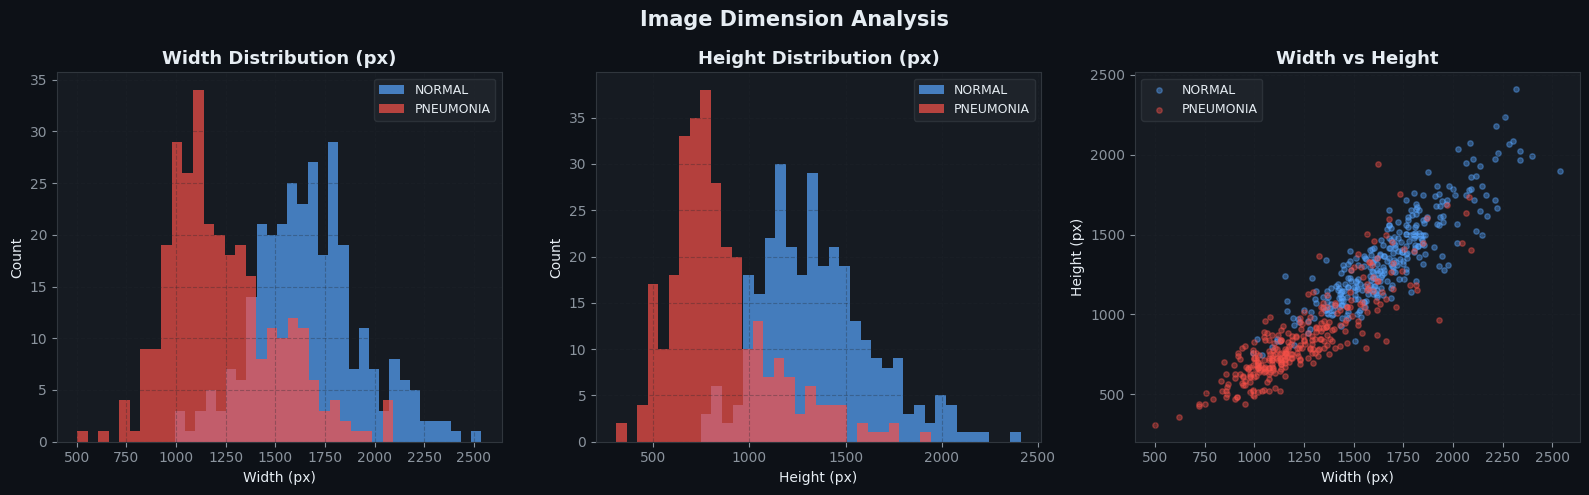

Saved: viz_03_dimensions.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='#0d1117')

for cls, color in COLORS.items():
    sub = df_dims[df_dims['Class'] == cls]

    # Width distribution
    axes[0].hist(sub['Width'], bins=30, alpha=0.7, color=color,
                 label=cls, edgecolor='none')

    # Height distribution
    axes[1].hist(sub['Height'], bins=30, alpha=0.7, color=color,
                 label=cls, edgecolor='none')

    # Scatter: Width vs Height
    axes[2].scatter(sub['Width'], sub['Height'], alpha=0.4,
                    color=color, s=15, label=cls)

titles = ['Width Distribution (px)', 'Height Distribution (px)',
          'Width vs Height']
xlabels = ['Width (px)', 'Height (px)', 'Width (px)']
ylabels = ['Count', 'Count', 'Height (px)']

for ax, title, xl, yl in zip(axes, titles, xlabels, ylabels):
    ax.set_title(title)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.legend(fontsize=9, facecolor='#21262d', edgecolor='#30363d',
              labelcolor='#e6edf3')
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#161b22')

fig.suptitle('Image Dimension Analysis', fontsize=15,
             fontweight='bold', color='#e6edf3')
plt.tight_layout()
plt.savefig('Visualization/viz_03_dimensions.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('Saved: viz_03_dimensions.png')

---
## 4. Pixel Intensity Statistics

In [7]:
# ── Memory-safe pixel stats ──
# Instead of storing all pixels (150M+ values → MemoryError),
# we accumulate a shared 256-bin histogram and per-image mean/std.
N_BINS     = 256
BIN_EDGES  = np.linspace(0, 1, N_BINS + 1)
RESIZE_TO  = (128, 128)   # resize before histogramming to keep RAM low
N_SAMPLES  = 200          # images per class

hist_data = {cls: np.zeros(N_BINS, dtype=np.float64) for cls in CLASSES}
mean_data = {cls: [] for cls in CLASSES}
std_data  = {cls: [] for cls in CLASSES}

for cls in CLASSES:
    folder = DATA_DIR / 'train' / cls
    paths  = sorted(folder.glob('*.jpeg'))[:N_SAMPLES]
    for p in paths:
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, RESIZE_TO)          # ← small fixed size
        img_norm = img.astype(np.float32) / 255.0
        counts, _ = np.histogram(img_norm, bins=BIN_EDGES)
        hist_data[cls] += counts                  # accumulate histogram
        mean_data[cls].append(float(img_norm.mean()))
        std_data[cls].append(float(img_norm.std()))
        del img, img_norm                         # free immediately

# Normalize histograms to density
for cls in CLASSES:
    total = hist_data[cls].sum()
    if total > 0:
        hist_data[cls] = hist_data[cls] / total

print('Pixel statistics (normalized 0-1, resized to 128×128):')
for cls in CLASSES:
    arr = np.array(mean_data[cls])
    print(f'  {cls:10s}: mean={arr.mean():.3f} ± {arr.std():.3f}')

Pixel statistics (normalized 0-1, resized to 128×128):
  NORMAL    : mean=0.470 ± 0.051
  PNEUMONIA : mean=0.485 ± 0.073


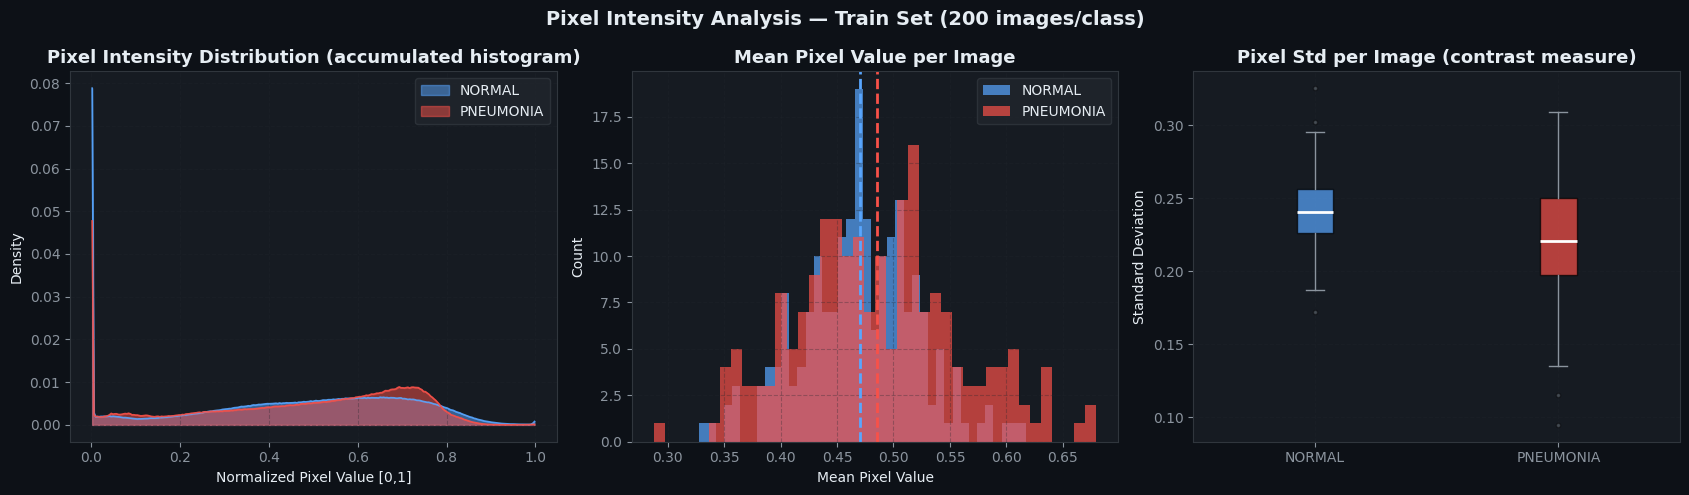

Saved: viz_04_pixel_stats.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), facecolor='#0d1117')
bin_centers = (BIN_EDGES[:-1] + BIN_EDGES[1:]) / 2

# ── 1. Accumulated pixel histogram (memory-safe) ──
for cls, color in COLORS.items():
    axes[0].fill_between(bin_centers, hist_data[cls], alpha=0.5,
                         color=color, label=cls)
    axes[0].plot(bin_centers, hist_data[cls], color=color,
                 linewidth=1.2, alpha=0.9)
axes[0].set_title('Pixel Intensity Distribution (accumulated histogram)')
axes[0].set_xlabel('Normalized Pixel Value [0,1]')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=10, facecolor='#21262d', edgecolor='#30363d',
               labelcolor='#e6edf3')

# ── 2. Mean per image ──
for cls, color in COLORS.items():
    axes[1].hist(mean_data[cls], bins=40, alpha=0.7, color=color,
                 label=cls, edgecolor='none')
    axes[1].axvline(np.mean(mean_data[cls]), color=color,
                    linestyle='--', linewidth=2)
axes[1].set_title('Mean Pixel Value per Image')
axes[1].set_xlabel('Mean Pixel Value')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=10, facecolor='#21262d', edgecolor='#30363d',
               labelcolor='#e6edf3')

# ── 3. Std per image (boxplot) ──
bp_data   = [std_data[cls] for cls in CLASSES]
bp_colors = list(COLORS.values())
bp = axes[2].boxplot(bp_data, labels=CLASSES, patch_artist=True,
                      medianprops={'color':'white','linewidth':2},
                      whiskerprops={'color':'#8b949e'},
                      capprops={'color':'#8b949e'},
                      flierprops={'marker':'o','markerfacecolor':'#8b949e',
                                  'markersize':3, 'alpha':0.4})
for patch, color in zip(bp['boxes'], bp_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_title('Pixel Std per Image (contrast measure)')
axes[2].set_ylabel('Standard Deviation')

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#161b22')

fig.suptitle('Pixel Intensity Analysis — Train Set (200 images/class)',
             fontsize=14, fontweight='bold', color='#e6edf3')
plt.tight_layout()
plt.savefig('Visualization/viz_04_pixel_stats.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('Saved: viz_04_pixel_stats.png')

---
## 5. Average Image per Class

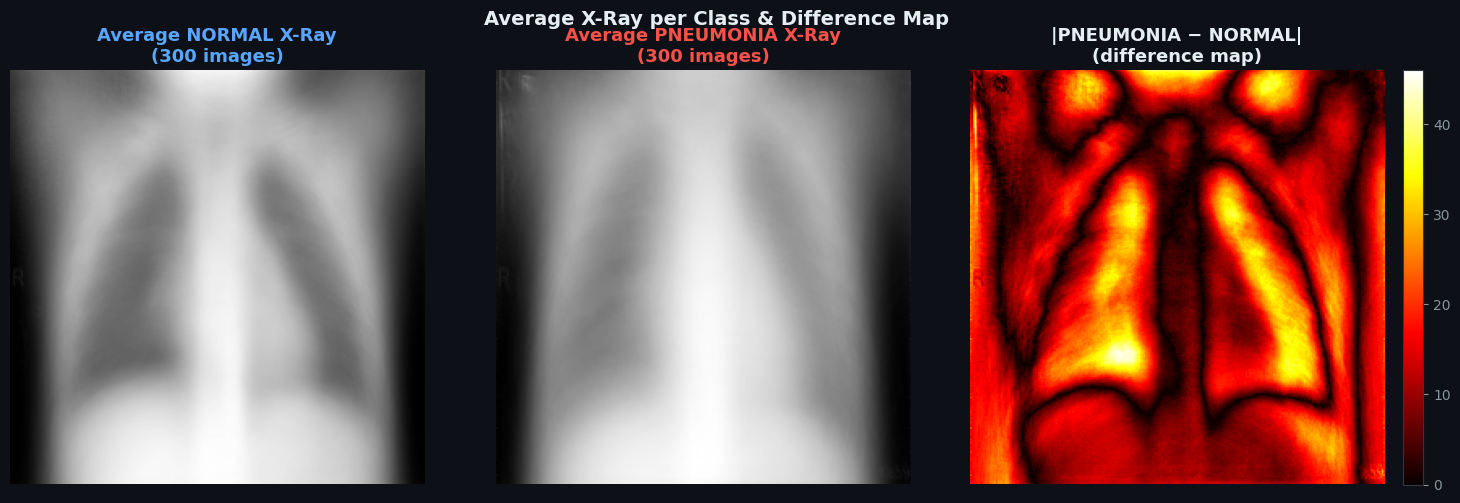

Saved: viz_05_average_images.png


In [ ]:
TARGET_SIZE = (256, 256)
avg_images  = {}

for cls in CLASSES:
    folder = DATA_DIR / 'train' / cls
    paths  = sorted(folder.glob('*.jpeg'))[:300]
    stack  = []
    for p in paths:
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, TARGET_SIZE)
            stack.append(img.astype(np.float64))
    avg_images[cls] = np.mean(stack, axis=0).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='#0d1117')

for i, cls in enumerate(CLASSES):
    axes[i].imshow(avg_images[cls], cmap='gray')
    axes[i].set_title(f'Average {cls} X-Ray\n(300 images)',
                      color=COLORS[cls], fontweight='bold')
    axes[i].axis('off')
    for spine in axes[i].spines.values():
        spine.set_edgecolor(COLORS[cls])
        spine.set_linewidth(3)
    axes[i].set_facecolor('#161b22')

# Difference image
diff = cv2.absdiff(avg_images['PNEUMONIA'], avg_images['NORMAL'])
im   = axes[2].imshow(diff, cmap='hot')
axes[2].set_title('|PNEUMONIA − NORMAL|\n(difference map)', fontweight='bold')
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

fig.suptitle('Average X-Ray per Class & Difference Map',
             fontsize=14, fontweight='bold', color='#e6edf3')
plt.tight_layout()
plt.savefig('Visualization/viz_05_average_images.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('Saved: viz_05_average_images.png')

---
## 6. HOG Feature Visualization

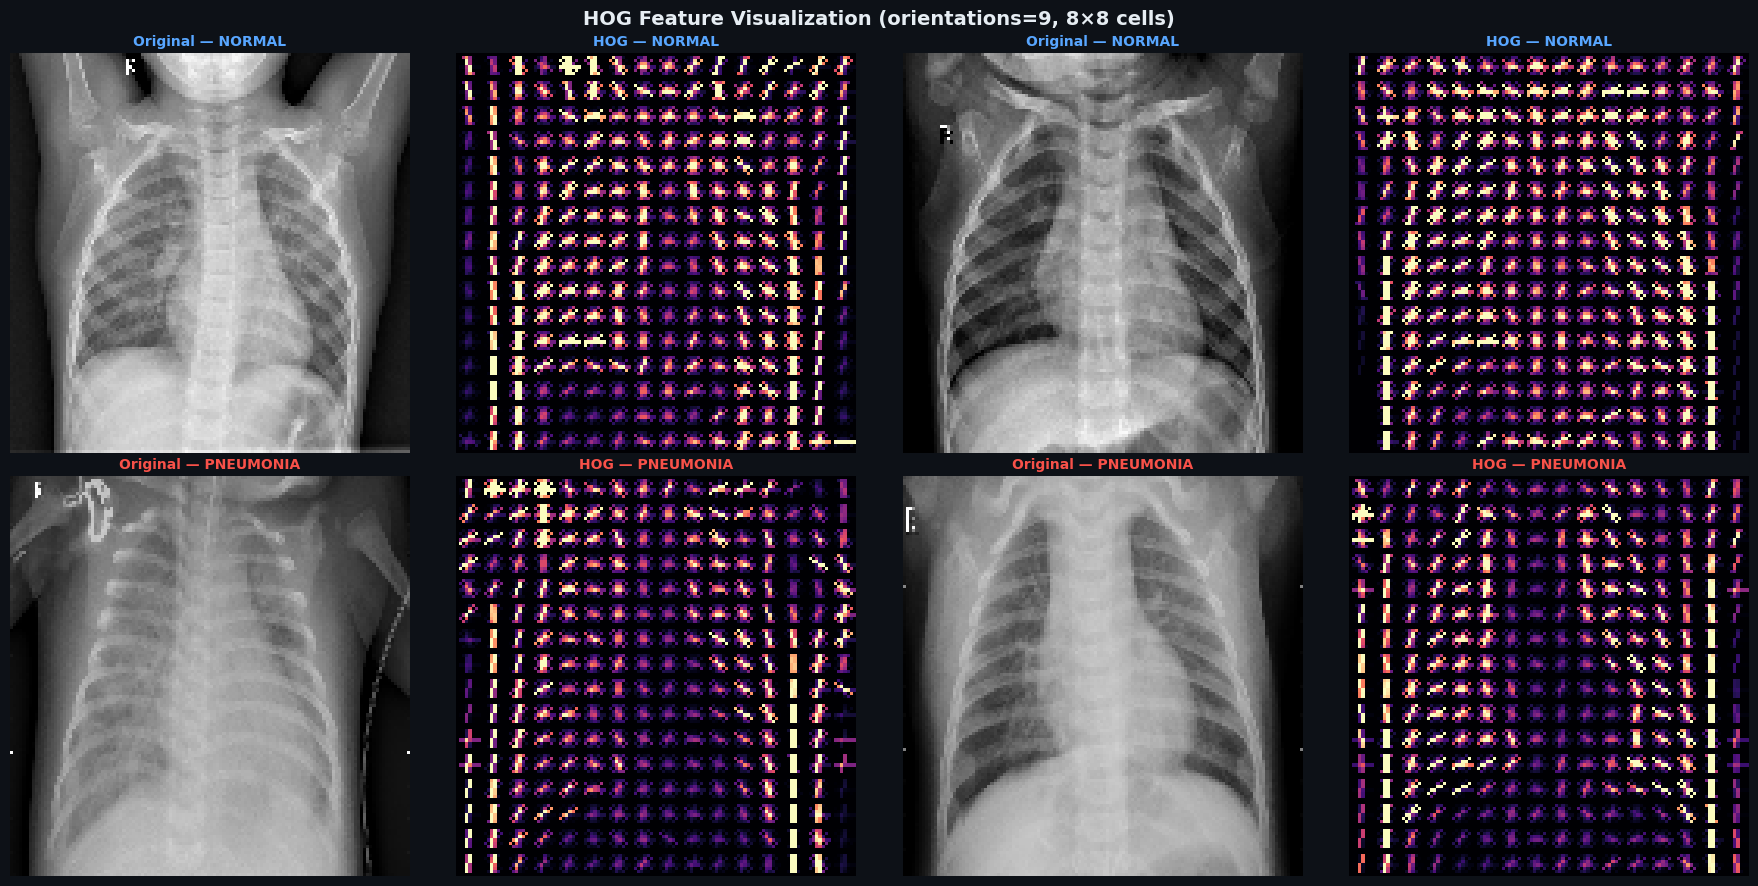

Saved: viz_06_hog_features.png


In [ ]:
def show_hog(ax_img, ax_hog, img_path, cls):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (128, 128))
    fd, hog_image = hog(
        img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=True,
        feature_vector=True,
    )
    hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
    ax_img.imshow(img, cmap='gray')
    ax_img.set_title(f'Original — {cls}', color=COLORS[cls], fontweight='bold', fontsize=10)
    ax_img.axis('off')
    ax_hog.imshow(hog_image_rescaled, cmap='magma')
    ax_hog.set_title(f'HOG — {cls}', color=COLORS[cls], fontweight='bold', fontsize=10)
    ax_hog.axis('off')
    return fd

fig, axes = plt.subplots(2, 4, figsize=(18, 9), facecolor='#0d1117')

for row, cls in enumerate(CLASSES):
    folder = DATA_DIR / 'train' / cls
    paths  = sorted(folder.glob('*.jpeg'))[:2]
    for col_offset, path in enumerate(paths):
        fd = show_hog(
            axes[row, col_offset*2],
            axes[row, col_offset*2+1],
            path, cls
        )

for ax in axes.flat:
    ax.set_facecolor('#161b22')

fig.suptitle('HOG Feature Visualization (orientations=9, 8×8 cells)',
             fontsize=14, fontweight='bold', color='#e6edf3')
plt.tight_layout()
plt.savefig('Visualization/viz_06_hog_features.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('Saved: viz_06_hog_features.png')

---
## 7. Data Augmentation Preview

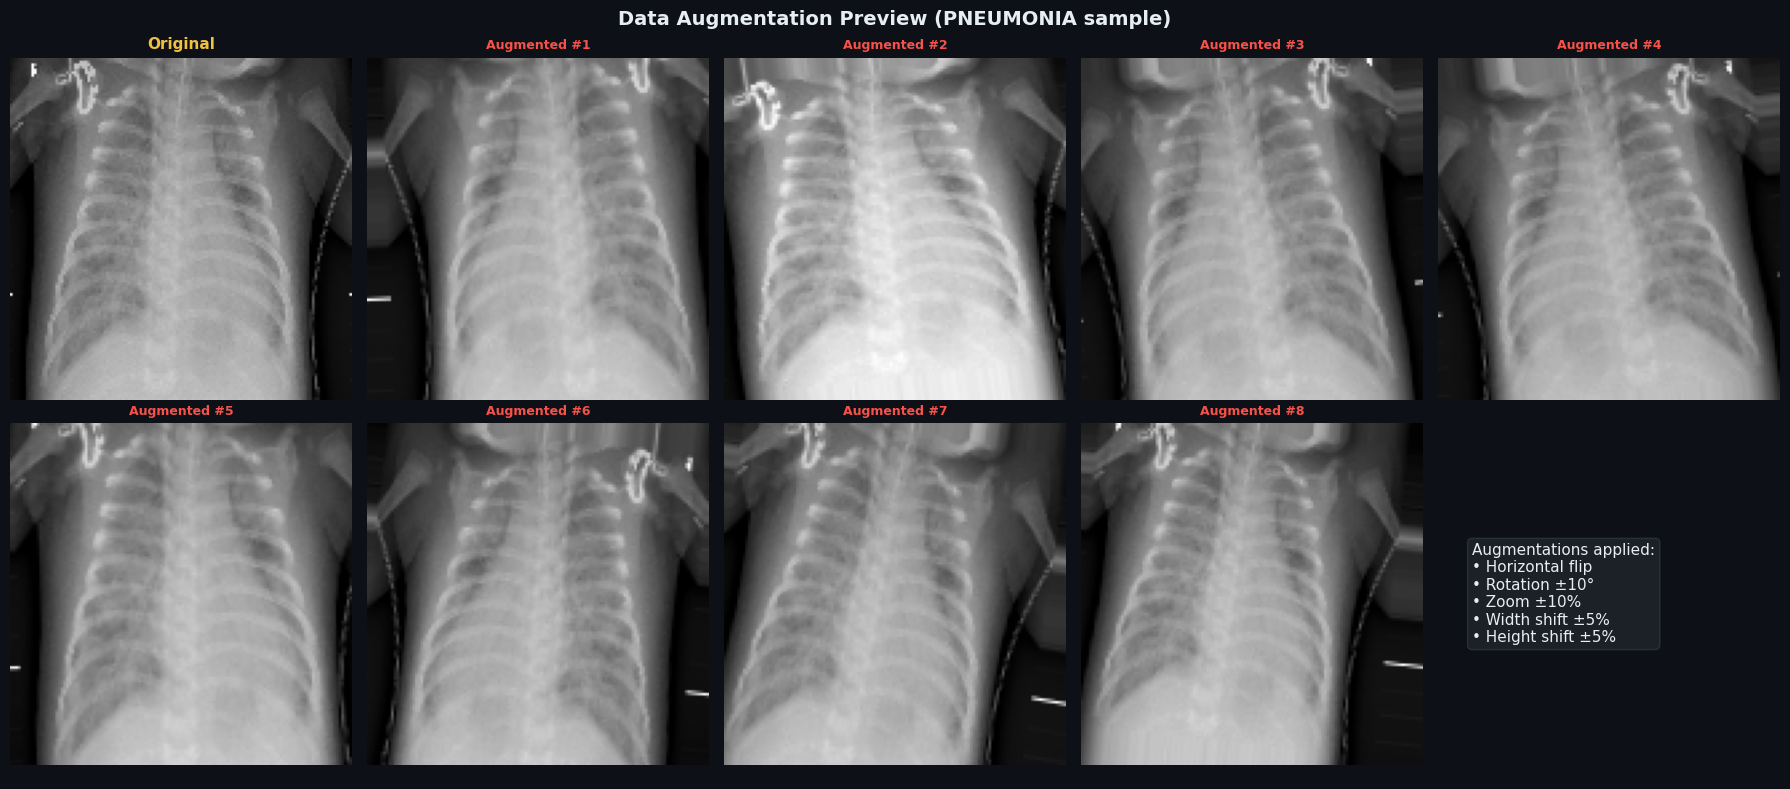

Saved: viz_07_augmentation.png


In [ ]:
# Pick one PNEUMONIA image and show 8 augmented versions
aug_path = sorted((DATA_DIR / 'train' / 'PNEUMONIA').glob('*.jpeg'))[0]
orig_img = cv2.imread(str(aug_path), cv2.IMREAD_GRAYSCALE)
orig_img = cv2.resize(orig_img, (128, 128))

datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
)

img_4d   = orig_img.reshape(1, 128, 128, 1).astype(np.float32) / 255.0
aug_imgs = [next(datagen.flow(img_4d, batch_size=1))[0,:,:,0] for _ in range(8)]

fig, axes = plt.subplots(2, 5, figsize=(18, 8), facecolor='#0d1117')

# Original
axes[0, 0].imshow(orig_img, cmap='gray')
axes[0, 0].set_title('Original', fontweight='bold', color='#f0c040', fontsize=11)
axes[0, 0].axis('off')
for spine in axes[0,0].spines.values():
    spine.set_edgecolor('#f0c040')
    spine.set_linewidth(2.5)

# Augmented
positions = [(0,1),(0,2),(0,3),(0,4),(1,0),(1,1),(1,2),(1,3)]
for idx, (r, c) in enumerate(positions):
    axes[r,c].imshow(aug_imgs[idx], cmap='gray')
    axes[r,c].set_title(f'Augmented #{idx+1}', fontsize=9, color='#f85149')
    axes[r,c].axis('off')
    axes[r,c].set_facecolor('#161b22')

axes[1,4].axis('off')

# Augmentation legend
aug_text = ('Augmentations applied:\n'
            '• Horizontal flip\n'
            '• Rotation ±10°\n'
            '• Zoom ±10%\n'
            '• Width shift ±5%\n'
            '• Height shift ±5%')
axes[1,4].text(0.1, 0.5, aug_text, transform=axes[1,4].transAxes,
               fontsize=11, color='#e6edf3', verticalalignment='center',
               bbox=dict(boxstyle='round', facecolor='#21262d', edgecolor='#30363d',
                         alpha=0.8))

for ax in axes.flat:
    ax.set_facecolor('#161b22')

fig.suptitle('Data Augmentation Preview (PNEUMONIA sample)',
             fontsize=14, fontweight='bold', color='#e6edf3')
plt.tight_layout()
plt.savefig('Visualization/viz_07_augmentation.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('Saved: viz_07_augmentation.png')

---
## 8. Class Imbalance Analysis

Class weights → NORMAL: 1.9448  |  PNEUMONIA: 0.6730


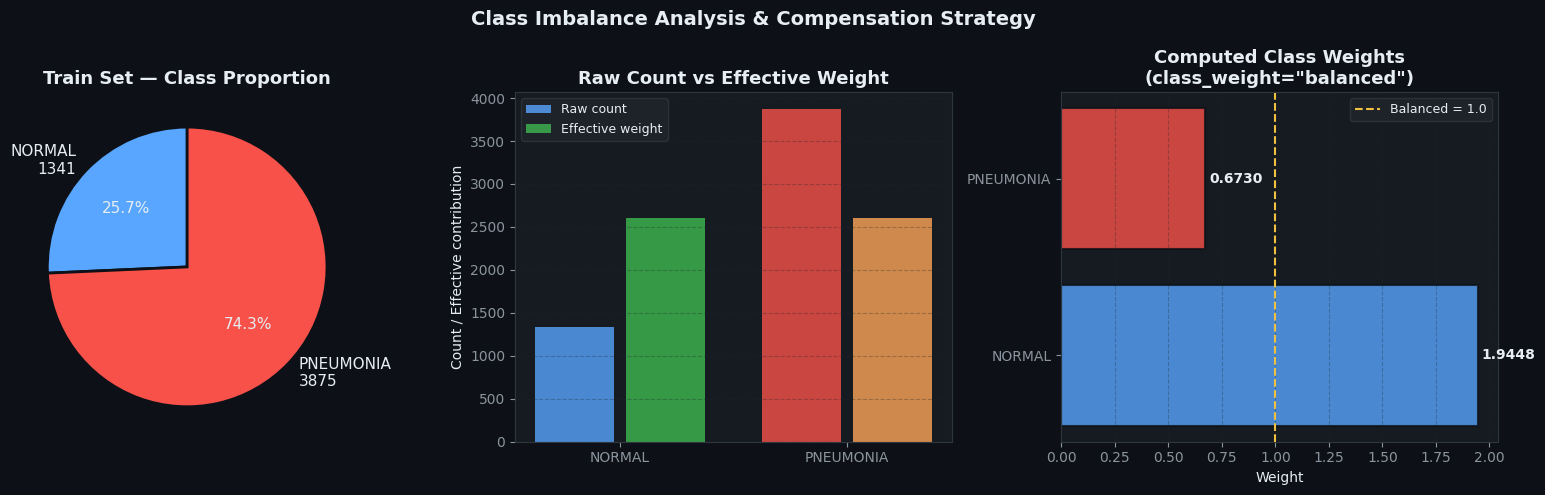

Saved: viz_08_class_imbalance.png


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Build label array for train set
n_normal    = df_counts[(df_counts.Split=='train') & (df_counts.Class=='NORMAL')]['Count'].values[0]
n_pneumonia = df_counts[(df_counts.Split=='train') & (df_counts.Class=='PNEUMONIA')]['Count'].values[0]
y_train     = np.array([0]*n_normal + [1]*n_pneumonia)

cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
class_weight_dict = {0: round(cw[0],4), 1: round(cw[1],4)}
print(f'Class weights → NORMAL: {cw[0]:.4f}  |  PNEUMONIA: {cw[1]:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='#0d1117')

# ── Pie chart ──
sizes  = [n_normal, n_pneumonia]
labels = [f'NORMAL\n{n_normal}', f'PNEUMONIA\n{n_pneumonia}']
wedge_props = {'linewidth': 2, 'edgecolor': '#0d1117'}
axes[0].pie(sizes, labels=labels, colors=PALETTE, autopct='%1.1f%%',
            startangle=90, wedgeprops=wedge_props,
            textprops={'color': '#e6edf3', 'fontsize': 11})
axes[0].set_title('Train Set — Class Proportion')
axes[0].set_facecolor('#161b22')

# ── Before vs After weighting ──
categories = ['NORMAL', 'PNEUMONIA']
raw_counts  = [n_normal, n_pneumonia]
weighted    = [n_normal * cw[0], n_pneumonia * cw[1]]
x = np.arange(2)
axes[1].bar(x - 0.2, raw_counts,  0.35, label='Raw count',      color=['#58a6ff','#f85149'], alpha=0.8)
axes[1].bar(x + 0.2, weighted,    0.35, label='Effective weight',color=['#3fb950','#ffa657'], alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].set_title('Raw Count vs Effective Weight')
axes[1].set_ylabel('Count / Effective contribution')
axes[1].legend(fontsize=9, facecolor='#21262d', edgecolor='#30363d',
               labelcolor='#e6edf3')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_facecolor('#161b22')

# ── Class weight bars ──
axes[2].barh(categories, [cw[0], cw[1]], color=PALETTE, alpha=0.8,
             edgecolor='#0d1117', linewidth=1.5)
for i, v in enumerate([cw[0], cw[1]]):
    axes[2].text(v + 0.02, i, f'{v:.4f}', va='center', color='#e6edf3', fontweight='bold')
axes[2].axvline(1.0, color='#f0c040', linestyle='--', linewidth=1.5, label='Balanced = 1.0')
axes[2].set_title('Computed Class Weights\n(class_weight="balanced")')
axes[2].set_xlabel('Weight')
axes[2].legend(fontsize=9, facecolor='#21262d', edgecolor='#30363d',
               labelcolor='#e6edf3')
axes[2].grid(axis='x', alpha=0.3)
axes[2].set_facecolor('#161b22')

fig.suptitle('Class Imbalance Analysis & Compensation Strategy',
             fontsize=14, fontweight='bold', color='#e6edf3')
plt.tight_layout()
plt.savefig('Visualization/viz_08_class_imbalance.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('Saved: viz_08_class_imbalance.png')

---
## 9. Summary — All Visualizations Generated

In [13]:
files = [
    ('viz_01_class_distribution.png', 'Class distribution per split'),
    ('viz_02_sample_images.png',      'Sample X-ray images'),
    ('viz_03_dimensions.png',         'Image dimension analysis'),
    ('viz_04_pixel_stats.png',        'Pixel intensity statistics'),
    ('viz_05_average_images.png',     'Average image + difference map'),
    ('viz_06_hog_features.png',       'HOG feature visualization'),
    ('viz_07_augmentation.png',       'Data augmentation preview'),
    ('viz_08_class_imbalance.png',    'Class imbalance & class weights'),
]

print('=' * 55)
print('  ✅  ALL VISUALIZATIONS GENERATED')
print('=' * 55)
for fname, desc in files:
    exists = '✓' if Path(fname).exists() else '✗'
    print(f'  {exists}  {fname:<38} {desc}')
print('=' * 55)

  ✅  ALL VISUALIZATIONS GENERATED
  ✓  viz_01_class_distribution.png          Class distribution per split
  ✓  viz_02_sample_images.png               Sample X-ray images
  ✓  viz_03_dimensions.png                  Image dimension analysis
  ✓  viz_04_pixel_stats.png                 Pixel intensity statistics
  ✓  viz_05_average_images.png              Average image + difference map
  ✓  viz_06_hog_features.png                HOG feature visualization
  ✓  viz_07_augmentation.png                Data augmentation preview
  ✓  viz_08_class_imbalance.png             Class imbalance & class weights
